# 02 · Comparativa de modelos

**Proyecto Final — Machine Learning y Deep Learning**

### Qué hace este notebook
**Entrenar** un modelo es mostrarle muchos ejemplos para que aprenda los patrones. Aquí **no entrenamos de nuevo**: cargamos los modelos que ya entrenó el proceso principal (`python -m src.train`), los **evaluamos** sobre datos que no vieron y los **comparamos** para elegir el mejor.

Comparamos cinco modelos de familias distintas (todos explicados en `docs/glosario.md`):
1. **Regresión logística** — modelo lineal sencillo (línea base).
2. **Árbol de decisión** — preguntas tipo sí/no encadenadas.
3. **Random Forest** — muchos árboles que votan (*ensemble*).
4. **XGBoost** — árboles que corrigen los errores de los anteriores (*boosting*).
5. **Red neuronal (Keras)** — capas de neuronas (*deep learning*).

> ⚠️ **Requisito:** ejecutar antes `python -m src.train` desde la carpeta `project/` para generar `models/*.pkl` (los modelos guardados) y `outputs/*.png` (los gráficos).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '3')  # silencia mensajes de TensorFlow

import warnings; warnings.filterwarnings('ignore')
import joblib, re                       # joblib: cargar modelos guardados (.pkl)
import pandas as pd
from IPython.display import Image, display

from src import config
from src.data_loader import load_and_prepare
from src.evaluator import Evaluator


## 1. Cargar los modelos entrenados y los datos de prueba

Reconstruimos la **misma división** train/test que usó el entrenamiento (gracias a la semilla fija `random_state = 42`, sale idéntica) y cargamos los cinco modelos guardados en disco. Cada modelo es un **Pipeline**: lleva dentro el preprocesado + el algoritmo, así que recibe los datos en crudo.

In [2]:
X_train, X_test, y_train, y_test = load_and_prepare()
print('Reservas para prueba (test):', len(X_test))

nombres = ['Logistic Regression', 'Decision Tree', 'Random Forest',
           'XGBoost', 'Neural Network (Keras)']
modelos = {}
for nombre in nombres:
    slug = re.sub(r'[^a-z0-9]+', '_', nombre.lower()).strip('_')
    modelos[nombre] = joblib.load(config.MODELS_DIR / f'{slug}.pkl')
print('Modelos cargados:', list(modelos))

Reservas para prueba (test): 23842


Modelos cargados: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost', 'Neural Network (Keras)']


## 2. Evaluación y tabla comparativa

Usamos la clase `Evaluator` (la misma del proceso principal) para calcular las métricas sobre el conjunto de prueba. Breve recordatorio (detalle en el glosario):

- **accuracy** (exactitud): % de aciertos totales.
- **precision** (precisión): de las que predije "cancela", cuántas lo eran.
- **recall** (sensibilidad): de las cancelaciones reales, cuántas detecté.
- **F1**: equilibrio entre precision y recall.
- **ROC-AUC**: capacidad de **ordenar** bien por riesgo (0.5 = azar, 1 = perfecto).

In [3]:
evaluator = Evaluator()
evaluator.evaluate(modelos, X_test, y_test)
tabla = evaluator.comparison_table()
# La tabla se ordena por la métrica principal; coloreamos para leerla mejor.
tabla.style.background_gradient(cmap='Greens', subset=config.METRIC_NAMES).format('{:.4f}')

,accuracy,precision,recall,f1,roc_auc
XGBoost,0.8826,0.8575,0.8195,0.8380,0.9548
Neural Network (Keras),0.8746,0.8502,0.8034,0.8262,0.9483
Random Forest,0.8611,0.8871,0.7165,0.7927,0.9431
Decision Tree,0.8542,0.8264,0.7680,0.7961,0.9337
Logistic Regression,0.8246,0.8045,0.6960,0.7464,0.9072


### ¿Por qué ROC-AUC como métrica principal?

1. **Robusta al desbalance** (~37 % de cancelaciones): no se deja engañar por la clase mayoritaria, como sí le pasa a la *accuracy*.
2. **No depende del umbral**: mide la capacidad de **ordenar** las reservas por riesgo. El *umbral* (el corte para decidir "cancela/no cancela", por defecto 0.5) puede ajustarse después según la política de *overbooking* del hotel.
3. **Comparable** entre algoritmos muy distintos.

Como métricas secundarias de negocio miramos **recall** (cancelaciones detectadas) y **F1** (equilibrio).

In [4]:
mejor = evaluator.select_best()
print('Mejor modelo según', config.PRIMARY_METRIC, '->', mejor)
tabla.loc[[mejor]]

Mejor modelo según roc_auc -> XGBoost


,accuracy,precision,recall,f1,roc_auc
XGBoost,0.88256,0.857481,0.819457,0.838038,0.954778


## 3. Curva ROC comparativa

La **curva ROC** muestra, para cada modelo, el equilibrio entre **detectar cancelaciones** (eje Y, *TPR*) y **dar falsas alarmas** (eje X, *FPR*) según el umbral. Cuanto más se acerca la curva a la **esquina superior izquierda**, mejor. El **AUC** (área bajo la curva) resume cada curva en un número.

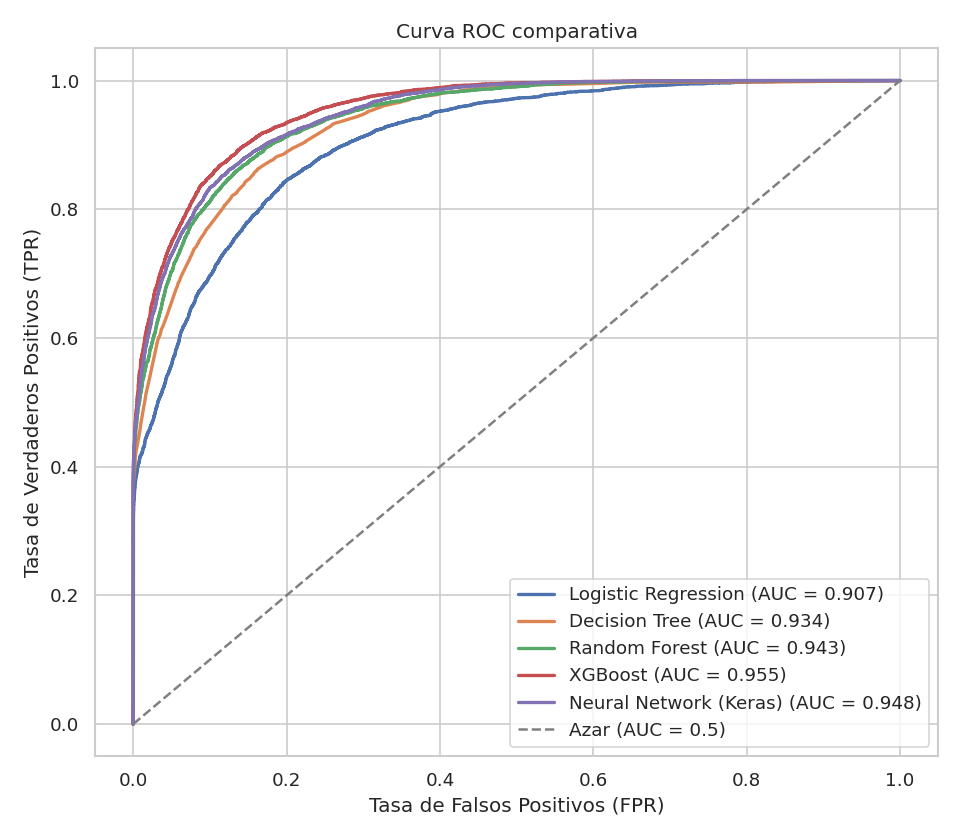

In [5]:
display(Image(filename=str(config.OUTPUTS_DIR / 'roc_curves.png')))

## 4. Matrices de confusión

La **matriz de confusión** cruza lo que el modelo **predijo** con lo que **realmente pasó**. Los **aciertos** están en la diagonal; fuera de ella, los errores: *falsos positivos* (falsa alarma) y *falsos negativos* (cancelación que se nos escapó).

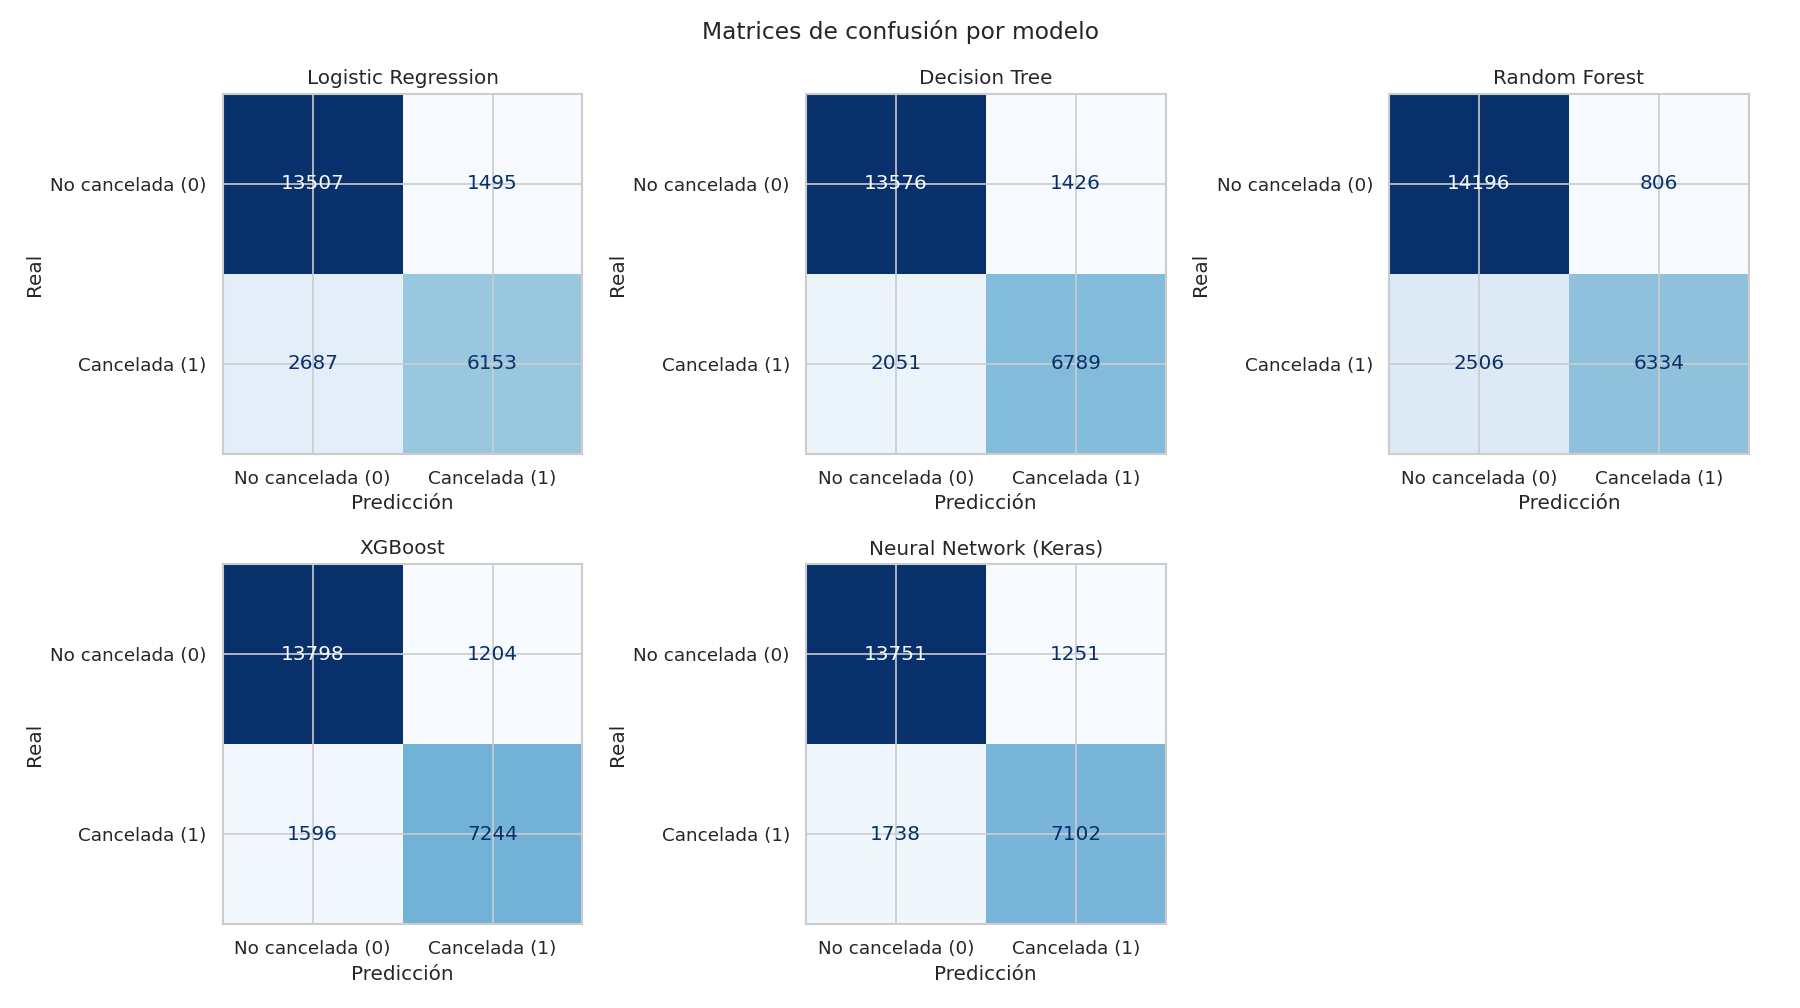

In [6]:
display(Image(filename=str(config.OUTPUTS_DIR / 'confusion_matrices.png')))

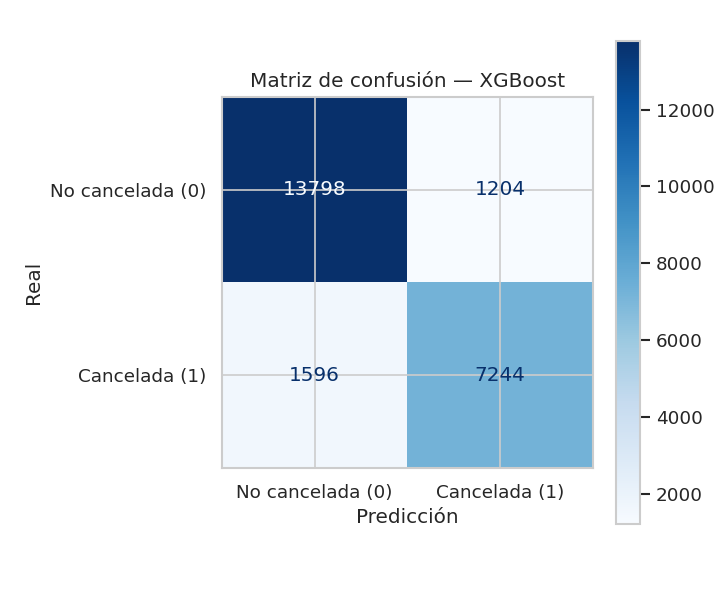

In [7]:
# Matriz de confusión solo del mejor modelo, con etiquetas claras
display(Image(filename=str(config.OUTPUTS_DIR / 'confusion_matrix_best.png')))

## 5. Importancia de variables (Random Forest)

La **importancia de variables** (*feature importances*) indica **cuánto influye cada característica** en las decisiones del modelo. Ayuda a *interpretar* el modelo: ver si "razona" con sentido.

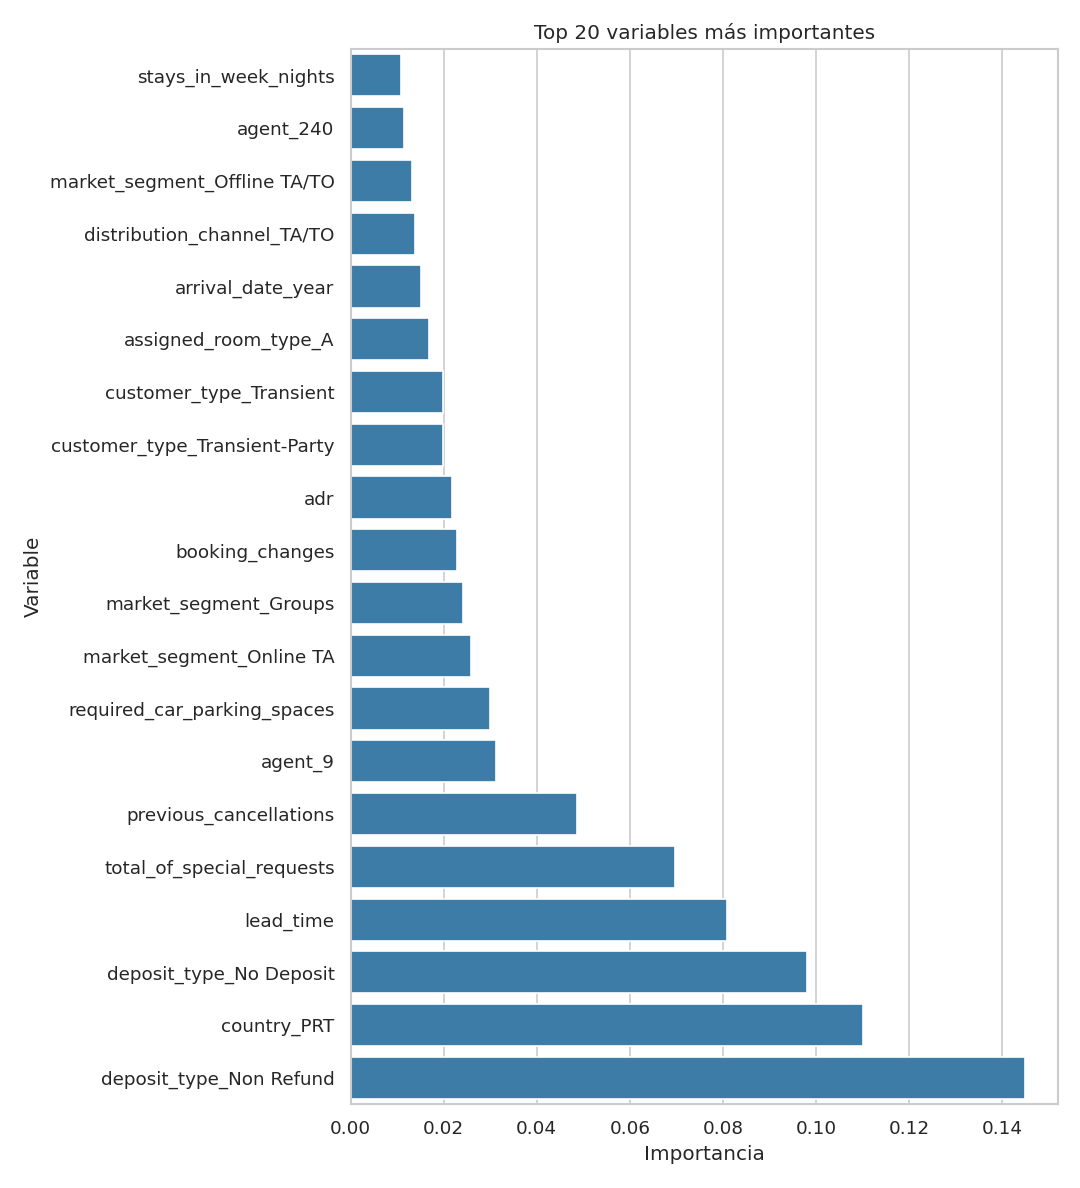

In [8]:
display(Image(filename=str(config.OUTPUTS_DIR / 'feature_importance.png')))

**Lectura.** Las variables más influyentes coinciden con lo que vimos en el EDA: `deposit_type=Non Refund` (depósito no reembolsable), `lead_time` (antelación), `adr` (precio), `country` (país) y `total_of_special_requests` (peticiones especiales) dominan la predicción. Que el modelo se apoye en variables que **tienen sentido** aumenta nuestra confianza en él.

## 6. Inferencia: usar el mejor modelo para predecir

**Inferencia** = usar un modelo ya entrenado sobre datos nuevos. Cargamos `best_model.pkl` y predecimos sobre una muestra. El modelo devuelve una **probabilidad** de cancelación (entre 0 y 1) y la decisión 0/1 aplicando el umbral 0.5.

In [9]:
from src.predict import load_best_model, predict_dataframe
from src.data_loader import load_raw_data

best = load_best_model()
muestra = load_raw_data().sample(8, random_state=config.RANDOM_STATE)
predict_dataframe(muestra, model=best)

,prediction,probability_canceled
30946,0,0.0997
40207,1,0.8676
103708,0,0.0046
85144,0,0.0819
109991,1,0.7380
110622,1,0.7580
47790,0,0.3954
44992,0,0.0008


## 7. Conclusión

**XGBoost** es el mejor modelo según ROC-AUC, seguido de cerca por la red neuronal y el Random Forest. Es el que se guarda como `models/best_model.pkl` para hacer predicciones. Los detalles, limitaciones y líneas de mejora están en `docs/informe_final.md`, y todos los términos en `docs/glosario.md`.